<h2>Simpson<h2>

In [1]:
from math import *
import matplotlib.pyplot as plt
import numpy as np

In [2]:
e = 0.0818191908426215
a = 6378137

def simpson(start, finish, phi):

    subs_list = []

    while start <= finish:
        subs_list.append(sqrt(1 - (pow(e, 2) * pow(cos(start), 2))))
        start += phi

    return ((4 * a) *
            (phi / 3) * 
            (subs_list[0] + 
             sum([(4 * sub) for sub in subs_list[1:len(subs_list)-1:2]]) + 
             sum([(2 * sub) for sub in subs_list[2:len(subs_list)-1:2]]) + 
             subs_list[len(subs_list)-1]))

In [3]:
simpson_01 = simpson(0, (pi / 2), 0.01) - 40007862.917


In [4]:
simpson_001 = simpson(0, (pi / 2), 0.001) - 40007862.917


In [5]:
simpson_0001 = simpson(0, (pi / 2), 0.0001)


<h2>Trapezoidal<h2>

In [6]:
e = 0.0818191908426215
a = 6378137

def trapezoidal(start, finish, phi):

    subs_list = []
    
    while start <= finish:
        subs_list.append(sqrt(1 - (pow(e, 2) * pow(cos(start), 2))))
        start += phi
        
    return ((4 * a) *
            (phi / 2) * 
            (subs_list[0] + 
             sum([(2 * sub) for sub in subs_list[1:len(subs_list)-1]]) + 
             subs_list[len(subs_list)-1]))

In [7]:
trapezoidal_01 = trapezoidal(0, (pi / 2), 0.01) - 40007862.917


In [8]:
trapezoidal_001 = trapezoidal(0, (pi / 2), 0.001) - 40007862.917


In [9]:
trapezoidal_0001 = trapezoidal(0, (pi / 2), 0.0001) 

<h2>RK1<h2>

In [10]:
e = 0.0818191908426215
a = 6378137

def RK1(start, finish, phi):

    subs_list = []

    while start < finish:
        subs_list.append(sqrt(1 - (pow(e, 2) * pow(cos(start), 2))))
        start += phi
        
    return ((4 * a) *
            (phi) * 
            (sum(subs_list)))

In [11]:
RK1_01 = RK1(0, (pi/2), 0.01) - 40007862.917


In [12]:
RK1_001 = RK1(0, (pi/2), 0.001) - 40007862.917


In [13]:
RK1_0001 = RK1(0, (pi/2), 0.0001) 


<h2>RK2<h2>

In [14]:
e = 0.0818191908426215
a = 6378137

def RK2(start, finish, phi):

    subs_list = []

    while start+(phi/2) < finish:
        subs_list.append(sqrt(1 - (pow(e, 2) * pow(cos(start+(phi/2)), 2))))
        start += phi 
        
    return ((4 * a) *
            (phi) * 
            (sum(subs_list)))
# correct the implementation (N)

In [15]:
RK2_01 = RK2(0, (pi/2), 0.01) - 40007862.917


In [16]:
RK2_001 = RK2(0, (pi/2), 0.001) - 40007862.917


In [17]:
RK2_0001 = RK2(0, (pi/2), 0.0001) 
RK2_0001 - 40007862.917


93.71307239681482

<h2>RK4<h2>

In [18]:
e = 0.0818191908426215
a = 6378137

def f(phi):
    return sqrt(1 - (pow(e, 2) * pow(cos(phi), 2)))

In [19]:
def RK4(start, finish, h):

    steps = int((finish - start) / h)

    subs_list1 = []
    subs_list2 = []
    subs_list3 = []
    subs_list4 = []

    for step in range(steps):
        phi = start + (step * h)
        k1 = f(phi)
        k2 = f(phi + (h/2))
        k3 = f(phi + (h/2))
        k4 = f(phi + h)
        subs_list1.append(k1)
        subs_list2.append(k2)
        subs_list3.append(k3)
        subs_list4.append(k4)
        
    return ((4 * a) *
            (h / 6) * 
            (sum(subs_list1) + (2 * sum(subs_list2)) + (2 * sum(subs_list3)) + sum(subs_list4)))

In [20]:
RK4_01 = RK4(0, (pi/2), 0.01) - 40007862.917

In [21]:
RK4_001 = RK4(0, (pi/2), 0.001) - 40007862.917

In [22]:
RK4_0001 = RK4(0, (pi/2), 0.0001)
RK4_0001 - 40007862.917

-2457.541727565229

<h2>Perimeter Of Ellipse<h2>

In [23]:
b = sqrt(pow(a, 2) - (pow((a * e), 2)))
a = 6378137

In [24]:
def ellipse_perimeter_calculator(a, b):

    h = pow(((a - b) / (a + b)), 2)

    kepler = 2 * pi * sqrt((a * b))
    arithmetical_mean = pi * (a + b)
    means_combo = pi * ((1.5 * (a + b)) - (sqrt(a * b)))
    best_means_estimation = (2 * pi) * (((1.32 / 2) * (a + b)) - (0.32 * sqrt(a * b)))
    linder = pi * (a + b) * (pow((1 + (h / 8)), 2))
    ramunajan_sec_est = pi * (a + b) * (1 + ((3 * h) / (10 + sqrt(4 - (3 * h)))))
    pade1 = pi * (a + b ) * ((64 + (3 * pow(h, 2))) / (64 - (16 * h)))
    pade2 = pi * (a + b) * (135168 - (85760 * h) - (5568 * pow(h, 2)) - (3867 * pow(h, 3))) / (135168 - (119552 * h) - (22208 * pow(h, 2)) - (345 * pow(h, 3)))

    return kepler, arithmetical_mean, means_combo, best_means_estimation, linder, ramunajan_sec_est, pade1, pade2

In [25]:
kepler, arithmetical_mean, means_combo, best_means_estimation, linder, ramunajan_sec_est, pade1, pade2 = ellipse_perimeter_calculator(a, b)

In [26]:
kepler

40007778.30720384

In [27]:
arithmetical_mean

40007834.71391182

In [28]:
means_combo

40007862.9172658

In [29]:
best_means_estimation

40007852.76405836

In [30]:
linder

40007862.917250894

In [31]:
ramunajan_sec_est

40007862.917250894

In [32]:
pade1

40007862.91728072

In [33]:
pade2 

40007862.91735542

<h2>Comparisons<h2>

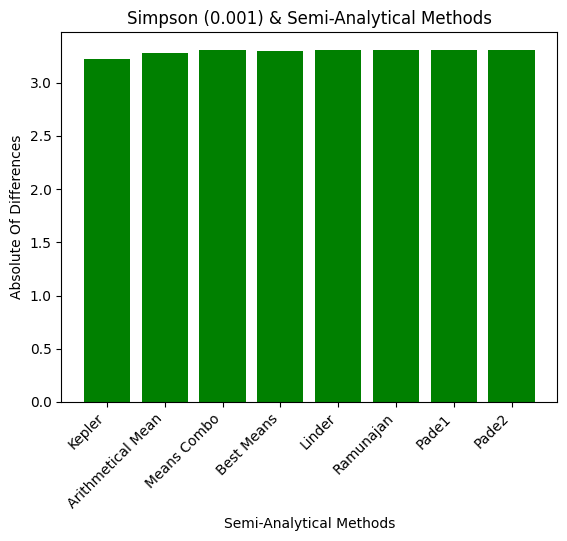

In [34]:
labels                  = ["Kepler", "Arithmetical Mean", "Means Combo", "Best Means", "Linder", "Ramunajan", "Pade1", "Pade2"]
semi_analytical_methods = [kepler, arithmetical_mean, means_combo, best_means_estimation, linder, ramunajan_sec_est, pade1, pade2]
values                  = [(val - simpson_0001) / 1000 for val in semi_analytical_methods]

plt.bar(labels, values, color="green")
plt.xlabel("Semi-Analytical Methods")
plt.ylabel("Absolute Of Differences")
plt.xticks(rotation=45, ha='right')
plt.title("Simpson (0.001) & Semi-Analytical Methods")
plt.show()

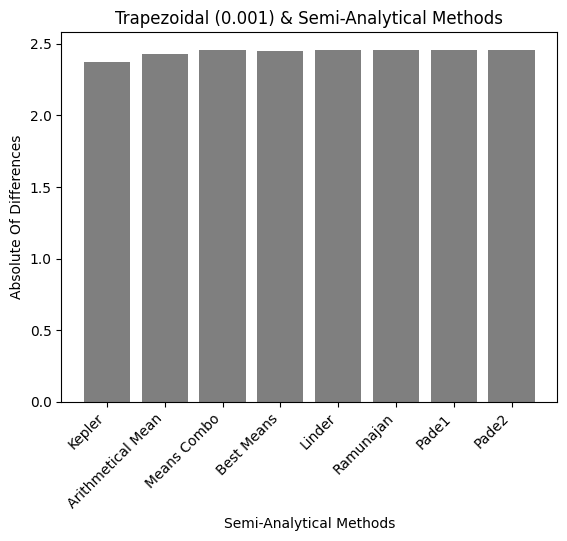

In [35]:
labels                  = ["Kepler", "Arithmetical Mean", "Means Combo", "Best Means", "Linder", "Ramunajan", "Pade1", "Pade2"]
semi_analytical_methods = [kepler, arithmetical_mean, means_combo, best_means_estimation, linder, ramunajan_sec_est, pade1, pade2]
values                  = [(val - trapezoidal_0001) / 1000 for val in semi_analytical_methods]

plt.bar(labels, values, color="tab:gray")
plt.xlabel("Semi-Analytical Methods")
plt.ylabel("Absolute Of Differences")
plt.xticks(rotation=45, ha='right')
plt.title("Trapezoidal (0.001) & Semi-Analytical Methods")
plt.show()

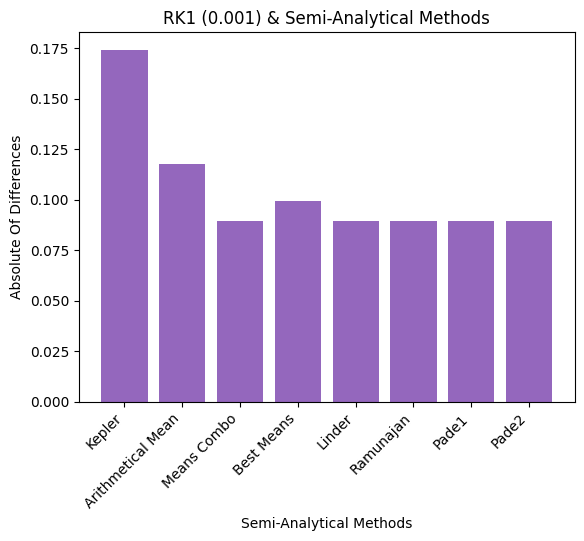

In [36]:
labels                  = ["Kepler", "Arithmetical Mean", "Means Combo", "Best Means", "Linder", "Ramunajan", "Pade1", "Pade2"]
semi_analytical_methods = [kepler, arithmetical_mean, means_combo, best_means_estimation, linder, ramunajan_sec_est, pade1, pade2]
values                  = [abs(val - RK1_0001) / 1000 for val in semi_analytical_methods]

plt.bar(labels, values, color="tab:purple")
plt.xlabel("Semi-Analytical Methods")
plt.ylabel("Absolute Of Differences")
plt.xticks(rotation=45, ha='right')
plt.title("RK1 (0.001) & Semi-Analytical Methods")
plt.show()

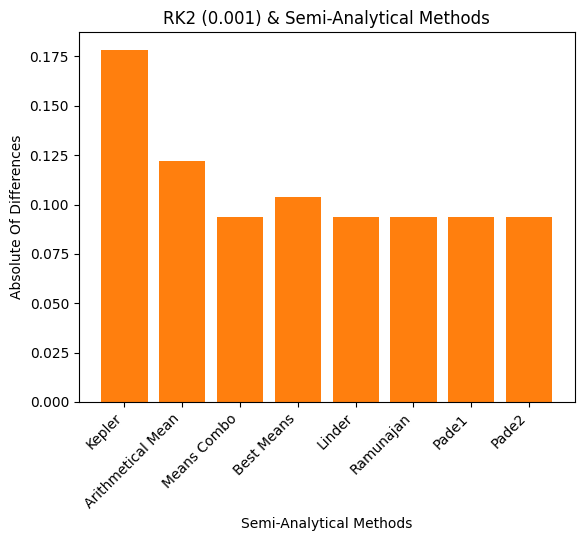

In [37]:
labels                  = ["Kepler", "Arithmetical Mean", "Means Combo", "Best Means", "Linder", "Ramunajan", "Pade1", "Pade2"]
semi_analytical_methods = [kepler, arithmetical_mean, means_combo, best_means_estimation, linder, ramunajan_sec_est, pade1, pade2]
values                  = [abs(val - RK2_0001) / 1000 for val in semi_analytical_methods]

plt.bar(labels, values, color="tab:orange")
plt.xlabel("Semi-Analytical Methods")
plt.ylabel("Absolute Of Differences")
plt.xticks(rotation=45, ha='right')
plt.title("RK2 (0.001) & Semi-Analytical Methods")
plt.show()

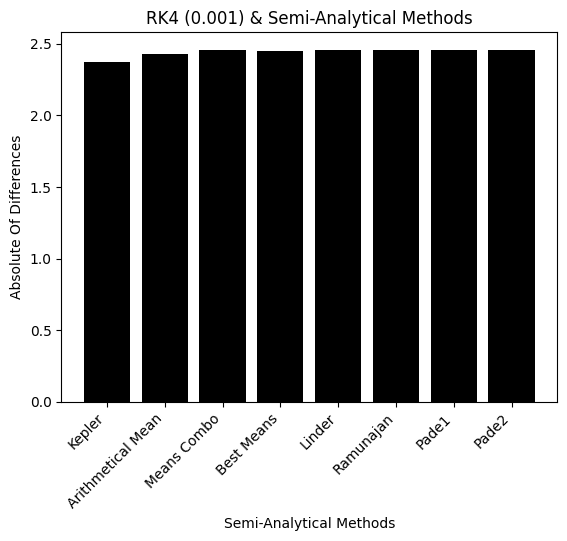

In [38]:
labels                  = ["Kepler", "Arithmetical Mean", "Means Combo", "Best Means", "Linder", "Ramunajan", "Pade1", "Pade2"]
semi_analytical_methods = [kepler, arithmetical_mean, means_combo, best_means_estimation, linder, ramunajan_sec_est, pade1, pade2]
values                  = [abs(val - RK4_0001) / 1000 for val in semi_analytical_methods]

plt.bar(labels, values, color="black")
plt.xlabel("Semi-Analytical Methods")
plt.ylabel("Absolute Of Differences")
plt.xticks(rotation=45, ha='right')
plt.title("RK4 (0.001) & Semi-Analytical Methods")
plt.show()

<h2>Arcs<h2>

In [39]:
e = 0.0818191908426215
a = 6378137

def M(phi):
    phi = np.deg2rad(phi)
    return ((a * (1 - e**2)) / ((1 - (e**2 * (sin(phi)**2)))) ** (3 / 2))

In [40]:
def RK2_M(start, finish, h_deg):
    # h_deg: step in degrees
    h = np.deg2rad(h_deg)   # step in radians
    subs_list = []

    phi = start
    while phi + h_deg/2 < finish:
        subs_list.append(M(phi + h_deg/2))
        phi += h_deg

    return h * sum(subs_list)   

In [41]:
Ms = []
phis = list(range(0, 90))

for i in range(0, 90):
    Ms.append(RK2_M(i, i+1, 0.01))

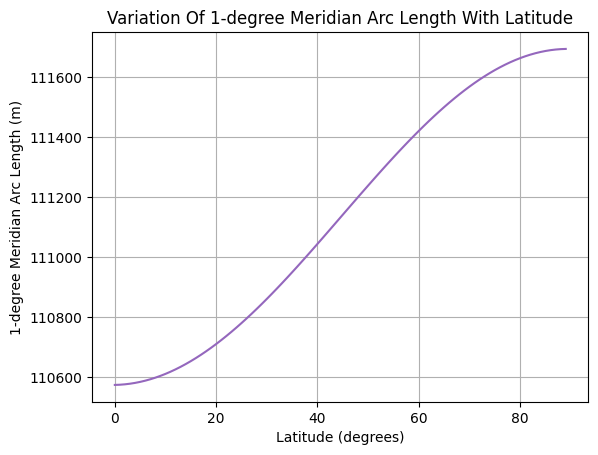

In [42]:
plt.plot(phis, Ms, color="tab:purple")
plt.xlabel("Latitude (degrees)")
plt.ylabel("1-degree Meridian Arc Length (m)")
plt.title("Variation Of 1-degree Meridian Arc Length With Latitude")
plt.grid(True)
plt.show()